In [31]:
# ============================================
# BASELINE FORECAST MODEL (UPDATED)
# Project FORESIGHT - NorthBay Living
# ============================================

"""
PURPOSE:
Create a baseline forecast using MULTIPLE METHODS
This becomes the benchmark that ALL ML models must beat

BASELINE METHODS:
1. Last Week's Sales (Naive)
2. Seasonal Naive (Same Week Last Year)
3. Rolling Mean (4-week average)

METRICS:
- WAPE (Weighted Absolute Percentage Error) - PRIMARY METRIC
- MAE (Mean Absolute Error)
- RMSE (Root Mean Square Error)
- MAPE (Mean Absolute Percentage Error)
- Bias (Over/Under forecasting)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')



In [32]:

print(" BASELINE FORECAST MODEL")
print("-" * 60)

# Load processed data
df = pd.read_csv('../data/processed/final_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df['launch_date'] = pd.to_datetime(df['launch_date'])

print(f"\n Loaded {len(df):,} records")
print(f" Date range: {df['date'].min()} to {df['date'].max()}")
print(f" Unique SKUs: {df['sku_id'].nunique()}")
print(f" Categories: {df['category'].nunique()}")



 BASELINE FORECAST MODEL
------------------------------------------------------------

 Loaded 40,352 records
 Date range: 2023-07-13 00:00:00 to 2024-12-31 00:00:00
 Unique SKUs: 149
 Categories: 9


In [33]:


def aggregate_to_weekly(df):
    """Convert daily data to weekly level per SKU"""
    
    # Add week and year columns
    df['year'] = df['date'].dt.year
    df['week'] = df['date'].dt.isocalendar().week
    
    # Aggregate by SKU, year, week
    weekly = df.groupby(['sku_id', 'category', 'year', 'week']).agg({
        'units_sold': 'sum',
        'revenue': 'sum',
        'unit_price': 'mean',
        'promo_flag': 'max',
        'on_hand_units': 'last',
        'on_order_units': 'last',
        'lead_time_days': 'last',
        'reorder_point': 'last'
    }).reset_index()
    
    # Create week_start_date for plotting
    weekly['week_start'] = weekly.apply(
        lambda row: datetime.strptime(f"{row['year']}-W{row['week']}-1", "%Y-W%W-%w"), 
        axis=1
    )
    
    return weekly

print("\n Aggregating to weekly level...")
weekly_df = aggregate_to_weekly(df)
print(f" Created {len(weekly_df):,} weekly records")
print(f"   Weeks: {weekly_df['week_start'].min()} to {weekly_df['week_start'].max()}")




 Aggregating to weekly level...
 Created 5,888 weekly records
   Weeks: 2023-07-10 00:00:00 to 2024-12-23 00:00:00


In [34]:

def create_baseline_forecasts(weekly_df):
    """
    Create multiple baseline forecasts
    1. Naive (last week's sales)
    2. Seasonal Naive (same week last year)
    3. Rolling Mean (4-week average)
    """
    
    # Sort by SKU and date
    weekly_df = weekly_df.sort_values(['sku_id', 'week_start'])
    
    # 1. Naive Forecast (last week's sales)
    weekly_df['naive_forecast'] = weekly_df.groupby('sku_id')['units_sold'].shift(1)
    
    # 2. Seasonal Naive (same week last year)
    weekly_df['seasonal_naive'] = weekly_df.groupby('sku_id')['units_sold'].shift(52)
    
    # 3. Rolling Mean (4-week average)
    weekly_df['rolling_mean_4'] = weekly_df.groupby('sku_id')['units_sold'].transform(
        lambda x: x.rolling(4, min_periods=1).mean()
    )
    
    # Fill NaN values
    weekly_df['naive_forecast'] = weekly_df['naive_forecast'].fillna(
        weekly_df['seasonal_naive']
    )
    weekly_df['naive_forecast'] = weekly_df['naive_forecast'].fillna(
        weekly_df['rolling_mean_4']
    )
    
    weekly_df['seasonal_naive'] = weekly_df['seasonal_naive'].fillna(
        weekly_df['rolling_mean_4']
    )
    
    # Best baseline = seasonal naive (usually better)
    weekly_df['baseline_forecast'] = weekly_df['seasonal_naive'].fillna(
        weekly_df['naive_forecast']
    )
    
    return weekly_df

print("\n Creating baseline forecasts...")
weekly_df = create_baseline_forecasts(weekly_df)
print(" Multiple baseline forecasts created")




 Creating baseline forecasts...
 Multiple baseline forecasts created


In [35]:


def train_test_split_weekly(weekly_df, test_weeks=8):
    """Split data into train and test sets (LAST 8 weeks for test)"""
    
    # Get unique week starts
    weeks = sorted(weekly_df['week_start'].unique())
    
    # Last 'test_weeks' weeks for testing
    test_start = weeks[-test_weeks]
    
    train_df = weekly_df[weekly_df['week_start'] < test_start].copy()
    test_df = weekly_df[weekly_df['week_start'] >= test_start].copy()
    
    return train_df, test_df

# Split data
print("\n Splitting data...")
train_df, test_df = train_test_split_weekly(weekly_df, test_weeks=8)

print(f"   Training data: {len(train_df):,} records")
print(f"   Test data: {len(test_df):,} records")
print(f"   Test weeks: {test_df['week_start'].min()} to {test_df['week_start'].max()}")




 Splitting data...
   Training data: 4,750 records
   Test data: 1,138 records
   Test weeks: 2024-11-04 00:00:00 to 2024-12-23 00:00:00


In [36]:

def calculate_wape(actual, forecast):
    """Calculate WAPE (Weighted Absolute Percentage Error)"""
    if sum(actual) == 0:
        return float('inf')
    return (sum(abs(actual - forecast)) / sum(actual)) * 100

def calculate_mape(actual, forecast):
    """Calculate MAPE (Mean Absolute Percentage Error)"""
    # Avoid division by zero
    mask = actual > 0
    if mask.sum() == 0:
        return float('inf')
    return (abs((actual[mask] - forecast[mask]) / actual[mask]).mean()) * 100

def calculate_mae(actual, forecast):
    """Calculate MAE (Mean Absolute Error)"""
    return abs(actual - forecast).mean()

def calculate_rmse(actual, forecast):
    """Calculate RMSE (Root Mean Square Error)"""
    return np.sqrt(((forecast - actual) ** 2).mean())

def calculate_bias(actual, forecast):
    """Calculate Bias (Mean Forecast Error)"""
    return (forecast - actual).mean()

def calculate_metrics(actual, forecast):
    """Calculate all metrics"""
    return {
        'WAPE': calculate_wape(actual, forecast),
        'MAPE': calculate_mape(actual, forecast),
        'MAE': calculate_mae(actual, forecast),
        'RMSE': calculate_rmse(actual, forecast),
        'Bias': calculate_bias(actual, forecast)
    }

print("\n Calculating baseline metrics...")




 Calculating baseline metrics...


In [37]:

print(" COMPARING ALL BASELINE METHODS")
print("=" * 60)

# Test each baseline method
methods = {
    'Naive (Last Week)': test_df['naive_forecast'],
    'Seasonal Naive': test_df['seasonal_naive'],
    'Rolling Mean (4wk)': test_df['rolling_mean_4']
}

best_method = None
best_wape = float('inf')

for name, forecast in methods.items():
    metrics = calculate_metrics(test_df['units_sold'], forecast)
    print(f"\n{name}:")
    print(f"  WAPE:  {metrics['WAPE']:.2f}%  ")
    print(f"  MAE:   {metrics['MAE']:.2f} units")
    print(f"  RMSE:  {metrics['RMSE']:.2f} units")
    print(f"  MAPE:  {metrics['MAPE']:.2f}%")
    print(f"  Bias:  {metrics['Bias']:.2f} units")
    
    if metrics['WAPE'] < best_wape:
        best_wape = metrics['WAPE']
        best_method = name

print(f"\n BEST BASELINE: {best_method} (WAPE: {best_wape:.2f}%)")



 COMPARING ALL BASELINE METHODS

Naive (Last Week):
  WAPE:  19.93%  
  MAE:   32.05 units
  RMSE:  64.98 units
  MAPE:  26.98%
  Bias:  14.64 units

Seasonal Naive:
  WAPE:  28.92%  
  MAE:   46.50 units
  RMSE:  83.65 units
  MAPE:  34.11%
  Bias:  21.54 units

Rolling Mean (4wk):
  WAPE:  18.28%  
  MAE:   29.40 units
  RMSE:  50.93 units
  MAPE:  22.79%
  Bias:  17.17 units

 BEST BASELINE: Rolling Mean (4wk) (WAPE: 18.28%)


In [38]:
# ============================================
# 7. OVERALL BASELINE METRICS
# ============================================

print("\n" + "=" * 60)
print(" BASELINE PERFORMANCE - OVERALL")
print("=" * 60)

overall_metrics = calculate_metrics(
    test_df['units_sold'], 
    test_df['baseline_forecast']
)

print(f"WAPE:  {overall_metrics['WAPE']:.2f}%  ⭐ PRIMARY METRIC")
print(f"MAE:   {overall_metrics['MAE']:.2f} units")
print(f"RMSE:  {overall_metrics['RMSE']:.2f} units")
print(f"MAPE:  {overall_metrics['MAPE']:.2f}%")
print(f"Bias:  {overall_metrics['Bias']:.2f} units")




 BASELINE PERFORMANCE - OVERALL
WAPE:  28.92%  ⭐ PRIMARY METRIC
MAE:   46.50 units
RMSE:  83.65 units
MAPE:  34.11%
Bias:  21.54 units


In [39]:

print(" BASELINE PERFORMANCE - BY CATEGORY")
print("-" * 60)

category_metrics = {}

for category in test_df['category'].unique():
    cat_test = test_df[test_df['category'] == category]
    metrics = calculate_metrics(
        cat_test['units_sold'],
        cat_test['baseline_forecast']
    )
    category_metrics[category] = metrics
    print(f"\n{category}:")
    print(f"  WAPE: {metrics['WAPE']:.2f}%")
    print(f"  MAE:  {metrics['MAE']:.2f} units")
    print(f"  MAPE: {metrics['MAPE']:.2f}%")

# Create category summary dataframe
cat_summary = pd.DataFrame(category_metrics).T
cat_summary = cat_summary.sort_values('WAPE')



 BASELINE PERFORMANCE - BY CATEGORY
------------------------------------------------------------

Decor:
  WAPE: 27.71%
  MAE:  45.24 units
  MAPE: 34.04%

Furniture:
  WAPE: 21.99%
  MAE:  27.18 units
  MAPE: 30.22%

Bedding:
  WAPE: 31.43%
  MAE:  64.43 units
  MAPE: 33.62%

Kitchen:
  WAPE: 26.29%
  MAE:  38.56 units
  MAPE: 28.64%

Bath:
  WAPE: 24.09%
  MAE:  38.75 units
  MAPE: 27.54%

Lighting:
  WAPE: 45.26%
  MAE:  52.57 units
  MAPE: 65.56%

Rugs:
  WAPE: 32.36%
  MAE:  44.99 units
  MAPE: 28.49%

Storage:
  WAPE: 29.76%
  MAE:  65.25 units
  MAPE: 38.69%

Unknown:
  WAPE: 12.73%
  MAE:  16.73 units
  MAPE: 13.42%


In [40]:

print(" BASELINE PERFORMANCE - TOP 10 WORST SKUS")
print("-" * 60)

sku_metrics = {}

for sku in test_df['sku_id'].unique():
    sku_test = test_df[test_df['sku_id'] == sku]
    if len(sku_test) >= 4:  # At least 4 weeks of test data
        metrics = calculate_metrics(
            sku_test['units_sold'],
            sku_test['baseline_forecast']
        )
        sku_metrics[sku] = metrics

# Sort by WAPE (worst first)
worst_skus = sorted(sku_metrics.items(), key=lambda x: x[1]['WAPE'], reverse=True)[:10]

for sku, metrics in worst_skus:
    print(f"\n{sku}:")
    print(f"  WAPE: {metrics['WAPE']:.2f}%")
    print(f"  MAE:  {metrics['MAE']:.2f} units")


 BASELINE PERFORMANCE - TOP 10 WORST SKUS
------------------------------------------------------------

SKU0070:
  WAPE: 133.23%
  MAE:  270.12 units

SKU0108:
  WAPE: 116.32%
  MAE:  174.62 units

SKU0106:
  WAPE: 94.31%
  MAE:  99.50 units

SKU0097:
  WAPE: 91.84%
  MAE:  73.12 units

SKU0161:
  WAPE: 89.32%
  MAE:  52.25 units

SKU0146:
  WAPE: 84.89%
  MAE:  78.62 units

SKU0095:
  WAPE: 80.93%
  MAE:  49.88 units

SKU0081:
  WAPE: 76.41%
  MAE:  170.50 units

SKU0167:
  WAPE: 73.74%
  MAE:  240.22 units

SKU0012:
  WAPE: 71.43%
  MAE:  7.50 units


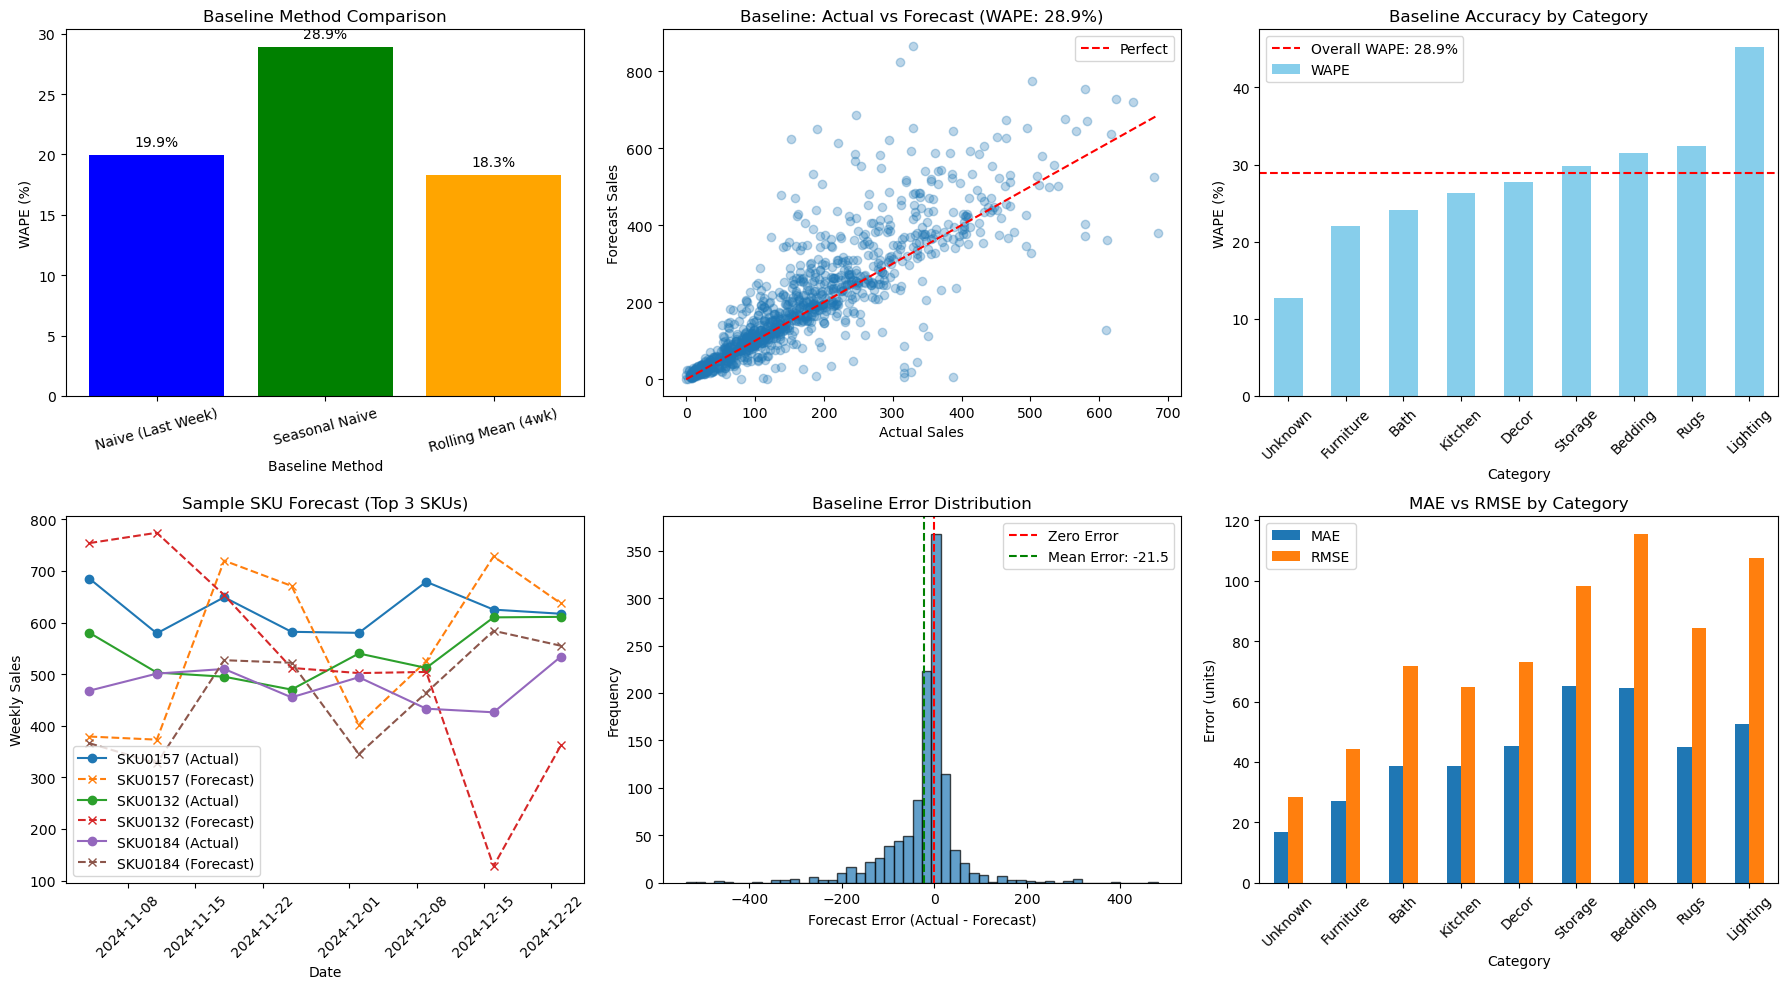

In [41]:

# ============================================
# 10. VISUALIZATION
# ============================================

# Figure 1: Overall Accuracy
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Baseline Method Comparison
ax1 = axes[0, 0]
wape_values = []
for name, forecast in methods.items():
    metrics = calculate_metrics(test_df['units_sold'], forecast)
    wape_values.append(metrics['WAPE'])
bars = ax1.bar(methods.keys(), wape_values, color=['blue', 'green', 'orange'])
ax1.set_xlabel('Baseline Method')
ax1.set_ylabel('WAPE (%)')
ax1.set_title('Baseline Method Comparison')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height:.1f}%', ha='center', va='bottom')
ax1.tick_params(axis='x', rotation=15)

# 2. Actual vs Forecast (Scatter)
ax2 = axes[0, 1]
ax2.scatter(test_df['units_sold'], test_df['baseline_forecast'], alpha=0.3)
ax2.plot([0, test_df['units_sold'].max()], [0, test_df['units_sold'].max()], 'r--', label='Perfect')
ax2.set_xlabel('Actual Sales')
ax2.set_ylabel('Forecast Sales')
ax2.set_title(f'Baseline: Actual vs Forecast (WAPE: {overall_metrics["WAPE"]:.1f}%)')
ax2.legend()

# 3. Category WAPE
ax3 = axes[0, 2]
cat_summary['WAPE'].sort_values().plot(kind='bar', ax=ax3, color='skyblue')
ax3.set_xlabel('Category')
ax3.set_ylabel('WAPE (%)')
ax3.set_title('Baseline Accuracy by Category')
ax3.axhline(y=overall_metrics['WAPE'], color='red', linestyle='--', label=f"Overall WAPE: {overall_metrics['WAPE']:.1f}%")
ax3.legend()
ax3.tick_params(axis='x', rotation=45)

# 4. Sample SKU Forecast (Top 3 SKUs)
ax4 = axes[1, 0]
top_skus = test_df.groupby('sku_id')['units_sold'].sum().nlargest(3).index

for sku in top_skus:
    sku_data = test_df[test_df['sku_id'] == sku].sort_values('week_start')
    ax4.plot(sku_data['week_start'], sku_data['units_sold'], marker='o', label=f'{sku} (Actual)')
    ax4.plot(sku_data['week_start'], sku_data['baseline_forecast'], '--', marker='x', label=f'{sku} (Forecast)')
ax4.set_xlabel('Date')
ax4.set_ylabel('Weekly Sales')
ax4.set_title('Sample SKU Forecast (Top 3 SKUs)')
ax4.legend()
ax4.tick_params(axis='x', rotation=45)

# 5. Error Distribution
ax5 = axes[1, 1]
errors = test_df['units_sold'] - test_df['baseline_forecast']
ax5.hist(errors, bins=50, edgecolor='black', alpha=0.7)
ax5.axvline(x=0, color='red', linestyle='--', label='Zero Error')
ax5.axvline(x=errors.mean(), color='green', linestyle='--', label=f'Mean Error: {errors.mean():.1f}')
ax5.set_xlabel('Forecast Error (Actual - Forecast)')
ax5.set_ylabel('Frequency')
ax5.set_title('Baseline Error Distribution')
ax5.legend()

# 6. MAE vs RMSE per Category
ax6 = axes[1, 2]
cat_summary[['MAE', 'RMSE']].plot(kind='bar', ax=ax6)
ax6.set_xlabel('Category')
ax6.set_ylabel('Error (units)')
ax6.set_title('MAE vs RMSE by Category')
ax6.legend()
ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/baseline_analysis.png', dpi=300, bbox_inches='tight')
plt.show()



In [42]:

test_df.to_csv('../data/processed/test_data_with_baseline.csv', index=False)

# Save metrics summary
summary = {
    'Metric': ['WAPE', 'MAE', 'RMSE', 'MAPE', 'Bias'],
    'Value': [
        overall_metrics['WAPE'],
        overall_metrics['MAE'],
        overall_metrics['RMSE'],
        overall_metrics['MAPE'],
        overall_metrics['Bias']
    ],
    'Target': ['< Baseline', 'Lower is Better', 'Lower is Better', 'Lower is Better', 'Near 0']
}
summary_df = pd.DataFrame(summary)
summary_df.to_csv('../reports/baseline_metrics.csv', index=False)

# Save category summary
cat_summary.to_csv('../reports/category_baseline_metrics.csv')


print(" BASELINE RESULTS SAVED")
print("-" * 60)
print(" test_data_with_baseline.csv")
print(" baseline_metrics.csv")
print(" category_baseline_metrics.csv")
print(" baseline_analysis.png")



 BASELINE RESULTS SAVED
------------------------------------------------------------
 test_data_with_baseline.csv
 baseline_metrics.csv
 category_baseline_metrics.csv
 baseline_analysis.png


In [43]:

print(" BASELINE TARGET - YOU MUST BEAT THIS!")
print("-"* 60)
print(f"\n TARGET: Model WAPE must be < {overall_metrics['WAPE']:.2f}%")
print(f"\n Current Baseline WAPE: {overall_metrics['WAPE']:.2f}%")

if overall_metrics['WAPE'] > 100:
    print(f"\n  WARNING: Baseline WAPE > 100% suggests very poor forecasting")
    print("   Consider using 'Same Week Last Year' instead of 'Last Week'")
else:
    print(f"\n Baseline is reasonable. Aim to reduce WAPE by at least 20%")



 BASELINE TARGET - YOU MUST BEAT THIS!
------------------------------------------------------------

 TARGET: Model WAPE must be < 28.92%

 Current Baseline WAPE: 28.92%

 Baseline is reasonable. Aim to reduce WAPE by at least 20%
